# Example: Pricing Zero-Coupon Treasury Bills Using NPV
This example computes zero-coupon U.S. Treasury bill prices using net present value (NPV). We compare the model results with reported auction prices and explore the relationships between bill prices, yields, and rate conventions.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
>
> * __Represent and price zero-coupon cash flows:__ Identify the purchase-date outflow and the single par-value receipt at maturity, then apply the zero-NPV condition under an explicitly stated yield convention.
> * __Translate rate conventions and reconcile prices:__ Use the published bank discount rate to reproduce the auction price, convert it to the nominal yield required by the NPV model, and compare equivalent rate conventions for the same bill.
> * __Relate bill prices and yields:__ Explain why a bill's price falls as its quoted bank discount rate rises, and compute that inverse relationship by perturbing the rate and repricing the bill.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
# Load the shared L2a paths, course environment, and package imports.
include(joinpath(@__DIR__, "Include.jl"));

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
Let's use U.S. Treasury bill auction data from October 2022 onward, downloaded with the [TreasuryDirect auction query](https://www.treasurydirect.gov/auctions/auction-query/).

We load the dataset using [the `MyTreasuryBillDataSet(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTreasuryBillDataSet) exported by the `VLQuantitativeFinancePackage`, which returns the auction records as [a `DataFrame` instance](https://dataframes.juliadata.org/stable/), newest auction first. We store the data in the `dataset::DataFrame` variable.

> __Returned data:__ Each row includes the published `Price` per $100$ USD of par, `High Rate` (the bank discount rate $d$), and `Investment Rate` ($y_I$). Both rates are stored as decimals. By default, the function [omits cash-management bills](https://www.treasurydirect.gov/marketable-securities/cash-management-bills/), which are irregular issues with terms quoted in days rather than weeks. Pass `cmb = true` to include them. The `from::Date` and `to::Date` keyword arguments restrict the auction-date range.

Load the auction records.

In [2]:
# Load the Treasury bill auction records supplied by the course package.
dataset = MyTreasuryBillDataSet()

Row,CUSIP,Security Type,Security Term,Auction Date,Issue Date,Maturity Date,Price,High Rate,Investment Rate
,String15,String7,String7,String15,String15,String15,Float64,Float64,Float64
1,912797WC7,Bill,26-Week,08/24/2026,08/27/2026,02/25/2027,98.0839,0.0379,0.03918
2,912797SU2,Bill,13-Week,08/24/2026,08/27/2026,11/27/2026,99.0506,0.03715,0.03803
3,912797VM6,Bill,8-Week,08/20/2026,08/25/2026,10/20/2026,99.4314,0.03655,0.03727
4,912797VD6,Bill,4-Week,08/20/2026,08/25/2026,09/22/2026,99.7169,0.0364,0.03701
5,912797WG8,Bill,17-Week,08/19/2026,08/25/2026,12/22/2026,98.7604,0.0375,0.0385
6,912797SA6,Bill,6-Week,08/18/2026,08/20/2026,10/01/2026,99.5747,0.03645,0.03711
7,912797UZ8,Bill,13-Week,08/17/2026,08/20/2026,11/19/2026,99.0609,0.03715,0.03802
8,912797TV9,Bill,26-Week,08/17/2026,08/20/2026,02/18/2027,98.089,0.0378,0.03907
9,912797VL8,Bill,8-Week,08/13/2026,08/18/2026,10/13/2026,99.4299,0.03665,0.03737


Store the number of auction records in `number_of_bills::Int64` using [the `nrow(...)` function from DataFrames.jl](https://dataframes.juliadata.org/stable/lib/functions/#DataAPI.nrow).

In [3]:
# Count the auction records available for the single-bill and full-sample calculations.
number_of_bills = nrow(dataset)

1145

___

## Task 1: Use the Published Discount Rate to Reproduce the Auction Price
A T-bill has two cash flows: the purchase price and the par amount paid at maturity. In this task, we use the published bank discount rate $d$ to reproduce the auction price, convert $d$ to the nominal yield required by the NPV model, and verify that both pricing expressions give the same result.

Construct a [`DiscreteCompoundingModel`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.DiscreteCompoundingModel) and store it in `discount_model`.

> The [`DiscreteCompoundingModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.DiscreteCompoundingModel) has no data associated with it. Instead, it is used [by the Julia multiple dispatch system](https://docs.julialang.org/en/v1/manual/methods/#Methods) so that we call the correct pricing methods later.

Build the discount model.

In [4]:
# Select discrete compounding for the NPV calculations in this notebook.
discount_model = DiscreteCompoundingModel();

Build a zero-coupon Treasury bill model using [`MyUSTreasuryZeroCouponBondModel`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.MyUSTreasuryZeroCouponBondModel) and the [`build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.build-Tuple{Type,NamedTuple}).

[The `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.build-Tuple{Type,NamedTuple}) requires the model type and [a `NamedTuple`](https://docs.julialang.org/en/v1/base/base/#Core.NamedTuple) of model data. We initially specify the par amount and $n=2$ compounding periods per year. Store the zero-coupon model in the `model::MyUSTreasuryZeroCouponBondModel` variable.

In [5]:
# Build a reusable T-bill model template. The price and timing fields are
# populated later after a specific auction record has been selected.
model = build(MyUSTreasuryZeroCouponBondModel, (
    par = 100.0, # face value repaid at maturity, in USD
    n = 2        # nominal-yield compounding periods per year
));

We'll need to set a rate for our model, but what rate should we use, and how do we set it? We can use [the `typeof(...)` function](https://docs.julialang.org/en/v1/base/base/#Core.typeof) in combination with [the `fieldnames(...)` function](https://docs.julialang.org/en/v1/base/base/#Base.fieldnames) to inspect the structure of our model, i.e., what data the model holds:

In [6]:
# Inspect the model fields that store its inputs and computed outputs.
typeof(model) |> T -> fieldnames(T)

(:par, :rate, :T, :price, :n, :cashflow, :discount)

The dataset reports three quantities for each auction: `Price`, the published price per $100$ USD of par; `High Rate`, the bank discount rate $d$; and `Investment Rate`, the coupon-equivalent yield $y_I$. We use the published $d$ as the pricing input because it appears directly in the Treasury formula developed in lecture.

Let $D$ be the actual days to maturity, let $B$ be the number of days in the year following the issue date ($365$ or $366$), and define the NPV year fraction $T=D/B$. The Treasury price computed from the published bank discount rate is given by:
$$
\boxed{V_B^{(d)}=V_P\left(1-d\frac{D}{360}\right)}.
$$
This calculated price should match the published `Price` to its six-decimal reporting precision. To express the same price in the NPV model, convert $d$ to the nominal annual yield $y_n$ compounded $n$ times per year:
$$
\boxed{y_n=n\left[\left(1-d\frac{D}{360}\right)^{-1/(nT)}-1\right]}.
$$
Substituting $y_n$ into the zero-coupon NPV expression returns the same price:
$$
V_B^{(\mathrm{NPV})}=V_P\left(1+\frac{y_n}{n}\right)^{-nT}=V_B^{(d)}.
$$
We can also express the same purchase price and maturity payment using the holding-period return $R$, continuously compounded annual growth rate $g$, or the simple investment rate $y_I$ implied by a short-duration bill:
$$
R=\frac{V_P}{V_B^{(d)}}-1,\qquad
g=\frac{1}{T}\log\left(\frac{V_P}{V_B^{(d)}}\right),\qquad
y_I=R\frac{B}{D}.
$$
Short-duration bills use this simple investment-rate expression; longer-maturity bills use Treasury's coupon-equivalent convention. However, $y_I$ is not needed for the $d\rightarrow V_B\rightarrow y_n$ pricing path used here. See [Treasury's official auction formulas](https://www.treasurydirect.gov/files/laws-and-regulations/auction-regulations-uoc/auct-reg-gsr-356122303.pdf).

`Unhide` the code cell below to see how we compute the various rates and prices.

In [7]:
(example_bill, auction_price, discount_formula_price, converted_bill_model, unconverted_bill_model, rate_comparison_table, price_comparison_table) = let

    # Select one auction and convert its calendar dates to the model's time units.
    selected_bill_index = 6; # fixed row keeps the worked example reproducible
    example_bill = dataset[selected_bill_index, :]; # complete auction record for the selected bill
    par = model.par; # face value paid at maturity, in USD
    n = model.n;     # nominal-yield compounding periods per year
    auction_price = example_bill[:Price]; # published price per 100 USD of par
    discount_rate = example_bill[Symbol("High Rate")]; # published bank discount rate d
    investment_rate = example_bill[Symbol("Investment Rate")]; # Treasury quotation as a decimal
    issue_date = Date(example_bill[Symbol("Issue Date")], dateformat"mm/dd/yyyy"); # parse text date
    maturity_date = Date(example_bill[Symbol("Maturity Date")], dateformat"mm/dd/yyyy"); # parse text date
    days_to_maturity = Dates.value(maturity_date - issue_date); # actual calendar days, D
    days_in_following_year = Dates.value((issue_date + Year(1)) - issue_date); # 365 or 366 days, B
    T = days_to_maturity / days_in_following_year; # actual-year fraction used by the NPV model

    # Reproduce the auction price directly from the published bank discount rate.
    discount_formula_price = par * (1 - discount_rate * days_to_maturity / 360);

    # Express the same purchase price and maturity payment under four rate conventions.
    holding_period_return = par / discount_formula_price - 1; # return relative to the amount invested
    simple_investment_rate = holding_period_return * days_in_following_year / days_to_maturity; # simple annualization
    continuous_rate = log(par / discount_formula_price) / T; # continuously compounded annual growth rate
    nominal_yield = n * ((par / discount_formula_price)^(1 / (n * T)) - 1); # nominal annual yield compounded n times

    # Reprice after converting d to the NPV model's nominal-yield convention.
    converted_bill_model = deepcopy(model); # preserve the reusable template
    converted_bill_model.T = T;              # set the actual-year maturity
    converted_bill_model.rate = nominal_yield; # set the compatible nominal yield
    converted_bill_model |> discount_model;  # populate price, factors, and cash flows

    # Price a second copy by incorrectly treating d as the nominal NPV yield.
    unconverted_bill_model = deepcopy(model); # keep the converted model unchanged
    unconverted_bill_model.T = T;             # use the same maturity
    unconverted_bill_model.rate = discount_rate; # intentional convention mismatch
    unconverted_bill_model |> discount_model; # compute the mismatched NPV price

    # Assemble one table for rate conventions and one for the resulting prices.
    rate_comparison_table = DataFrame(
        convention = [
            "Published bank discount rate d",
            "Published investment rate y_I",
            "Price-implied simple investment rate",
            "Price-implied nominal yield y_n",
            "Price-implied continuous rate g"
        ],
        annual_rate_percent = 100 .* [
            discount_rate, investment_rate, simple_investment_rate, nominal_yield, continuous_rate
        ]
    );
    price_comparison_table = DataFrame(
        method = [
            "Published auction price",
            "Treasury formula from d",
            "NPV after converting d to y_n",
            "NPV using d without conversion"
        ],
        price_per_100_USD_par = [
            auction_price, discount_formula_price, converted_bill_model.price, unconverted_bill_model.price
        ],
        difference_from_discount_formula_per_100_USD_par = [
            auction_price - discount_formula_price, 0.0,
            converted_bill_model.price - discount_formula_price,
            unconverted_bill_model.price - discount_formula_price
        ]
    );

    # Return every object needed by the display and verification cells below.
    (example_bill, auction_price, discount_formula_price, converted_bill_model,
        unconverted_bill_model, rate_comparison_table, price_comparison_table)
end;

### Compare the Rate Conventions
Let's compare the five annualized rates for the selected T-bill. 

The left column names the rate convention, and the right column gives the annual rate as a percentage. The first two rows are the published Treasury rates. The final three rows are implied by the price computed from $d$ under simple, nominal semiannual, and continuous compounding. 

All five rows describe the same purchase price and maturity payment; the numerical rates differ because the conventions use different denominators, day-count rules, and compounding rules.

In [8]:
# Display all rate conventions as annual percentages to four decimal places.
pretty_table(rate_comparison_table;
    column_labels = ["Rate convention", "Annual rate (%)"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.4f", [2])])

======================================= ==================
                       Rate convention   Annual rate (%) 
======================================= ==================
        Published bank discount rate d            3.6450
         Published investment rate y_I            3.7110
  Price-implied simple investment rate            3.7114
       Price-implied nominal yield y_n            3.7380
       Price-implied continuous rate g            3.7035
======================================= ==================


### Compare the Prices
Let's now compare the prices. 

The first row is the published `Price`. The second is the Treasury price calculated directly from the published $d$. The third is the NPV price after converting $d$ to $y_n$; it should equal the second row. The fourth intentionally uses the unconverted $d$ as the NPV yield. The final column is each row's signed difference from the Treasury formula in the second row.

In [9]:
# Display each price and its difference from the Treasury formula using d.
pretty_table(price_comparison_table;
    column_labels = ["Method", "Price per 100 USD par", "Difference per 100 USD par (USD)"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.6f", [2, 3])])

================================= ======================= ===================================
                          Method   Price per 100 USD par   Difference per 100 USD par (USD) 
================================= ======================= ===================================
         Published auction price               99.574750                           0.000000
         Treasury formula from d               99.574750                           0.000000
   NPV after converting d to y_n               99.574750                           0.000000
  NPV using d without conversion               99.585214                           0.010464
================================= ======================= ===================================


The assertions below verify the two price match:

In [10]:
# Check each step of the rate-conversion round trip.
@assert isapprox(auction_price, discount_formula_price; atol = 5e-7) # published d reproduces the reported price
@assert isapprox(converted_bill_model.price, discount_formula_price; atol = 1e-12) # converted yield reproduces the same price
@assert !isapprox(unconverted_bill_model.price, discount_formula_price; atol = 1e-6) # unconverted d gives a different NPV price

### Compare Unconverted-Rate Errors Across Bill Terms
Let's repeat the calculation for every regular bill in the dataset. For each auction, we compute price from the published $d$, convert $d$ to $y_n$, and verify the NPV price. We then intentionally use $d$ as the unconverted NPV yield. The displayed error is the absolute difference between that incorrect NPV price and the Treasury price computed from $d$.

`Unhide` the code block below to see how we run this calculation. The hidden code constructs the complete `pricing_comparison_table::DataFrame`, and we build a table that summarizes the mean and maximum convention error per $100$ USD par for each bill term.

In [11]:
(pricing_comparison_table, convention_error_summary) = let

    # Initialize the row collection and one reusable 100 USD par pricing model.
    comparison_rows = NamedTuple[]; # one rate-convention comparison per auction
    comparison_model = build(MyUSTreasuryZeroCouponBondModel, (
        par = 100.0, # report every price and error per 100 USD of par
        n = 2        # nominal-yield compounding periods per year
    ));

    # Price and convert every regular bill in the dataset.
    for i ∈ 1:number_of_bills
        # Read the published discount rate and convert the dates to calendar quantities.
        auction_price = dataset[i, :Price]; # published price per 100 USD of par
        discount_rate = dataset[i, Symbol("High Rate")]; # published bank discount rate d
        issue_date = Date(dataset[i, Symbol("Issue Date")], dateformat"mm/dd/yyyy");
        maturity_date = Date(dataset[i, Symbol("Maturity Date")], dateformat"mm/dd/yyyy");
        days_to_maturity = Dates.value(maturity_date - issue_date); # actual calendar days, D
        days_in_following_year = Dates.value((issue_date + Year(1)) - issue_date); # 365 or 366 days, B
        T = days_to_maturity / days_in_following_year; # actual-year fraction

        # Compute the Treasury price from d, then infer the model-compatible nominal yield.
        discount_formula_price = comparison_model.par *
            (1 - discount_rate * days_to_maturity / 360);
        nominal_yield = comparison_model.n * (
            (comparison_model.par / discount_formula_price)^(1 / (comparison_model.n * T)) - 1
        ); # nominal annual yield compounded comparison_model.n times per year

        # Reprice with the converted yield; this price should close the round trip.
        comparison_model.T = T;
        comparison_model.rate = nominal_yield;
        converted_npv_price = comparison_model |> discount_model |> x -> x.price;

        # Reprice by incorrectly treating d as the nominal yield.
        comparison_model.rate = discount_rate; # intentional convention mismatch
        unconverted_npv_price = comparison_model |> discount_model |> x -> x.price;
        unconverted_rate_error_per_100 = abs(unconverted_npv_price - discount_formula_price);

        # Store the auction inputs, calculated prices, and error measures.
        push!(comparison_rows, (
            CUSIP = dataset[i, :CUSIP],
            term = dataset[i, Symbol("Security Term")],
            days = days_to_maturity,
            discount_rate_percent = 100 * discount_rate,
            auction_price = auction_price,
            discount_formula_price = discount_formula_price,
            converted_npv_price = converted_npv_price,
            unconverted_npv_price = unconverted_npv_price,
            unconverted_rate_error_USD_per_100_par = unconverted_rate_error_per_100,
            published_price_rounding_error_per_100 = abs(auction_price - discount_formula_price),
            conversion_error_per_100 = abs(converted_npv_price - discount_formula_price)
        ));
    end

    # Group the auction-level results by standard Treasury bill term.
    pricing_comparison_table = DataFrame(comparison_rows);
    convention_error_summary = combine(
        groupby(pricing_comparison_table, :term),
        :days => minimum => :minimum_days, # shortest observed maturity in the term group
        :days => maximum => :maximum_days, # longest observed maturity in the term group
        nrow => :auctions,                 # number of auctions in the term group
        :unconverted_rate_error_USD_per_100_par => mean => :mean_unconverted_rate_error_USD_per_100_par,
        :unconverted_rate_error_USD_per_100_par => maximum => :maximum_unconverted_rate_error_USD_per_100_par,
        :conversion_error_per_100 => maximum => :maximum_conversion_error_per_100
    );
    sort!(convention_error_summary, :minimum_days); # order terms from shortest to longest

    # Verify both the published Treasury prices and the converted NPV prices.
    @assert maximum(pricing_comparison_table.published_price_rounding_error_per_100) < 5e-7
    @assert maximum(pricing_comparison_table.conversion_error_per_100) < 1e-10

    (pricing_comparison_table, convention_error_summary) # return detail and summary tables
end;

# Select only the columns shown to students.
summary_display = select(convention_error_summary, :term, :auctions,
    :mean_unconverted_rate_error_USD_per_100_par,
    :maximum_unconverted_rate_error_USD_per_100_par);

# Display errors caused by using d as the unconverted NPV yield.
pretty_table(summary_display;
    column_labels = ["Term", "Auctions", "Mean unconverted-d error (USD/100 par)",
        "Maximum unconverted-d error (USD/100 par)"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.6f", [3, 4])])

========== ========== ======================================== ============================================
     Term   Auctions   Mean unconverted-d error (USD/100 par)   Maximum unconverted-d error (USD/100 par) 
========== ========== ======================================== ============================================
   4-Week        203                                 0.009446                                    0.014813
   6-Week         79                                 0.011592                                    0.013866
   8-Week        203                                 0.020248                                    0.028603
  13-Week        204                                 0.035243                                    0.048160
  17-Week        201                                 0.048750                                    0.066597
  26-Week        204                                 0.081277                                    0.113465
  52-Week         51                     

___

## Task 2: Compute T-Bill Prices at Different Bank Discount Rates
Malkiel proposed five theorems describing how fixed-income prices respond to yield and maturity. The first of these theorems is that, for fixed promised cash flows and a fixed quotation convention, T-bill/note/bond prices move inversely with yield.

> __Theorem 1__
> 
> Bond prices move inversely to bond yields: [Malkiel, B. G. (1962). Expectations, Bond Prices, and the Term Structure of Interest Rates. The Quarterly Journal of Economics, 76(2), 197–218](https://www.jstor.org/stable/1880816)

Malkiel proved Theorem 1 analytically. Here, we test the relationship computationally. Select a random bill from `dataset::DataFrame` using [Julia's `rand(...)` function](https://docs.julialang.org/en/v1/stdlib/Random/#Base.rand). we'll use this bill to test __Theorem 1.__

In [12]:
# Select one auction record at random for the price-yield experiment.
random_bill_index = rand(1:number_of_bills);
println("Selected bill: $(random_bill_index)")

Selected bill: 953


Display the selected T-bill.

In [13]:
# Display every auction field for the selected bill.
dataset[random_bill_index, :]

Row,CUSIP,Security Type,Security Term,Auction Date,Issue Date,Maturity Date,Price,High Rate,Investment Rate
,String15,String7,String7,String15,String15,String15,Float64,Float64,Float64
953,912797GG6,Bill,8-Week,06/15/2023,06/20/2023,08/15/2023,99.2098,0.0508,0.05206


Next, compute the selected bill's Treasury price directly from its published bank discount rate $d$, then convert $d$ into the nominal semiannual yield expected by the package model. Then we build a zero-coupon model for the selected bill using the `build(...)` function, and compute the NPV price. The NPV price should equal the Treasury price computed from $d$.

The resulting `zero_coupon_model` stores the same two cash flows as the selected bill: the negative purchase price at time zero and the positive par payment at maturity. See the [DataFrames.jl documentation for examples of accessing data from a `DataFrame` instance](https://dataframes.juliadata.org/stable/man/basics/). 

In [14]:
# Read the selected quotation and convert its dates to an actual-year maturity.
selected_bill = dataset[random_bill_index, :]; # complete auction record
selected_par = 100.0; # face value used for all prices in this experiment, in USD
selected_n = 2;       # nominal-yield compounding periods per year
selected_issue_date = Date(selected_bill[Symbol("Issue Date")], dateformat"mm/dd/yyyy");
selected_maturity_date = Date(selected_bill[Symbol("Maturity Date")], dateformat"mm/dd/yyyy");
selected_discount_rate = selected_bill[Symbol("High Rate")]; # published bank discount rate d
selected_days_to_maturity = Dates.value(selected_maturity_date - selected_issue_date); # actual days, D
selected_days_in_following_year = Dates.value((selected_issue_date + Year(1)) - selected_issue_date); # days, B
selected_T = selected_days_to_maturity / selected_days_in_following_year; # actual-year fraction, D/B

# Compute price from d, then infer the model-compatible nominal yield.
selected_discount_formula_price = selected_par *
    (1 - selected_discount_rate * selected_days_to_maturity / 360);
selected_nominal_yield = selected_n * (
    (selected_par / selected_discount_formula_price)^(1 / (selected_n * selected_T)) - 1
); # nominal annual yield compounded semiannually

# Build and price a zero-coupon model using the converted yield.
zero_coupon_model = build(MyUSTreasuryZeroCouponBondModel, (
    par = selected_par, n = selected_n, T = selected_T, rate = selected_nominal_yield
)) |> discount_model;

#### Verify the Converted NPV Price
The price computed from $d$ should match the published auction price to its six-decimal reporting precision. After conversion, the NPV model should match the price computed from $d$ to floating-point precision.

In [15]:
# Establish the published price and the price computed from d.
auction_price = selected_bill[:Price];       # published price per 100 USD of par
computed_price = selected_discount_formula_price; # baseline for the rate perturbations below

# Check the Treasury formula and the converted NPV model.
@assert isapprox(auction_price, computed_price; atol = 5e-7)
@assert isapprox(zero_coupon_model.price, computed_price; atol = 1e-12)

#### Inspect the Cash Flows
The cash flow events for the T-bill are stored in the `cashflow::Dict{Int64, Float64}` dictionary of the zero-coupon model. For a zero-coupon T-bill, there are only two cash flows:  An initial investment (negative $V_{B}$ cash flow at time `0`), and the payoff of par value $V_{P}$ (positive cash flow) at maturity (at time `1`).

So what do we see?

In [16]:
# Inspect the signed purchase-date and maturity-date cash flows.
zero_coupon_model.cashflow

Dict{Int64, Float64} with 2 entries:
  0 => -99.2098
  1 => 100.0

### Set the Bank-Discount-Rate Range
Let $d$ denote the published bank discount rate. To simulate its price effect while holding par amount and maturity fixed, generate $d\leftarrow\beta d$. If $\beta<1$, the discount rate decreases; if $\beta=1$, it is unchanged; and if $\beta>1$, it increases.

* First, we specify the number of perturbation values we want to consider; we store this value in the `number_of_samples` variable. If `number_of_samples` is odd, the perturbation range will include the published discount rate as the center value.
* Next, we specify the lower and upper values of the perturbation range; the lower bound is stored in the `β₁` variable, while the upper bound is stored in the `β₂` variable.
* Finally, we compute the perturbation array (stored in the `β`-variable) using the [range function](https://docs.julialang.org/en/v1/base/math/#Base.range) in combination with the [Julia pipe |> operator](https://docs.julialang.org/en/v1/manual/functions/#Function-composition-and-piping), and [the Julia collect function](https://docs.julialang.org/en/v1/base/collections/#Base.collect-Tuple{Type,%20Any}), which converts a range type to a collection, i.e., an array

Build the rate-scaling array.

In [17]:
# Define seven multipliers from 0.8 to 1.2 for the published discount rate.
number_of_samples = 7; # number of rate-and-price scenarios
β₁ = 0.8;              # lowest rate multiplier
β₂ = 1.2;              # highest rate multiplier
β = range(β₁, stop = β₂, length = number_of_samples) |> collect; # scenario grid

### Compute Prices at Different Bank Discount Rates
Compute the selected T-bill's price at different bank discount rates $d$ and store the results in the `theorem_1_simulation_array::Array{Float64,2}` variable. Iterate through each value of the $\beta$ array using a for loop, where we use the [eachindex function](https://docs.julialang.org/en/v1/base/arrays/#Base.eachindex). 

For iteration $i$ of the loop:
* Get a perturbation $\beta_i$ from the $\beta$ array and compute $d_i=\beta_i d$.
* Recompute price from $V_{B,i}=V_P(1-d_iD/360)$ using the unchanged par amount and maturity
* Store the discount-rate multiplier $\beta_{i}$ in column 1 and the percentage price change from the published-rate baseline in column 2 of the `theorem_1_simulation_array`.
* Store the perturbed discount rate and new price in columns 3 and 4, respectively.

Run the simulation.

In [18]:
theorem_1_simulation_array = let

    # Initialize one row per multiplier with columns
    # [rate multiplier, price change (%), perturbed rate, perturbed price].
    theorem_1_simulation_array = Array{Float64,2}(undef, number_of_samples, 4);
    baseline_discount_rate = selected_discount_rate; # published bank discount rate
    
    # Reprice the same bill after scaling only its bank discount rate.
    for i ∈ eachindex(β)
        β_value = β[i]; # rate multiplier for scenario i
        perturbed_discount_rate = β_value * baseline_discount_rate; # d_new = βd
        
        # Use the same par value and maturity so the rate is the only changing input.
        perturbed_price = zero_coupon_model.par *
            (1 - perturbed_discount_rate * selected_days_to_maturity / 360);
        
        # Store the scenario inputs and outputs in the documented column order.
        theorem_1_simulation_array[i,1] = β_value; # rate multiplier
        theorem_1_simulation_array[i,2] =
            100 * (perturbed_price - computed_price) / computed_price; # price change (%)
        theorem_1_simulation_array[i,3] = perturbed_discount_rate; # decimal rate
        theorem_1_simulation_array[i,4] = perturbed_price; # USD per 100 USD of par
    end

    theorem_1_simulation_array # return the populated scenario matrix
end;

# Display the simulation with labeled columns while preserving the stored decimal rates.
let
    display_array = copy(theorem_1_simulation_array);
    display_array[:,3] .*= 100; # convert d from decimal form to percent for display

    pretty_table(display_array;
        column_labels = ["Discount-rate multiplier β", "Price change from baseline (%)",
            "Bank discount rate d (%)", "Price (USD/100 par)"],
        table_format = TextTableFormat(borders = text_table_borders__simple),
        fit_table_in_display_horizontally = false,
        formatters = [fmt__printf("%.4f", [1, 3]),
            fmt__printf("%.6f", [2, 4])])
end

============================= ================================ ========================== ======================
  Discount-rate multiplier β   Price change from baseline (%)   Bank discount rate d (%)   Price (USD/100 par) 
============================= ================================ ========================== ======================
                      0.8000                         0.159303                     4.0640             99.367822
                      0.8667                         0.106202                     4.4027             99.315141
                      0.9333                         0.053101                     4.7413             99.262459
                      1.0000                         0.000000                     5.0800             99.209778
                      1.0667                        -0.053101                     5.4187             99.157096
                      1.1333                        -0.106202                     5.7573             99.104

### Plot Discount-Rate Changes Against Price Changes
`Unhide` the code block to see how we plotted the percentage change in the T-bill price versus the $\beta$ parameter, which scales the published bank discount rate $d$. The case $\beta=1$ leaves the rate unchanged, while $\beta<1$ decreases it and $\beta>1$ increases it.

__Expected result:__ The T-bill price decreases as $\beta$, and therefore $d$, increases. so what do we see?

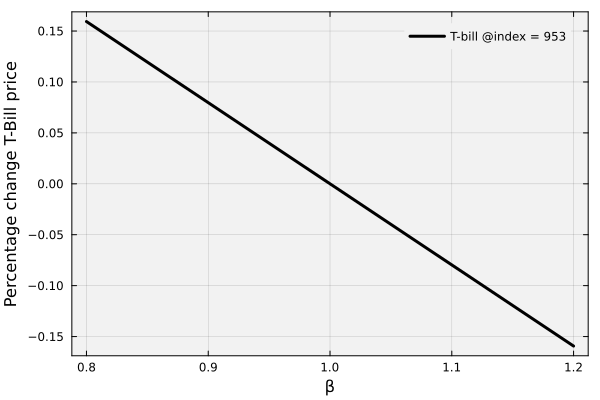

In [19]:
let
    # Create the plot canvas and use a boxed frame for the classroom display.
    q = plot(bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent);

    # Plot rate multiplier β against the resulting percentage price change.
    plot(q, theorem_1_simulation_array[:,1], theorem_1_simulation_array[:,2];
        lw = 3, c = :black, xlabel = "β", ylabel = "Percentage change T-Bill price",
        label = "T-bill @index = $(random_bill_index)")
end

### Verify That Price Falls as the Discount Rate Rises
If price is inversely related to the bank discount rate, then the slope of price versus $d$ should be negative. Compute the slope from the simulation array and store it in `slope`.

> __Check:__ Use the [`@assert` macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert) to verify that the slope is negative. The test throws an [`AssertionError`](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError) if the condition fails.

Compute and verify the slope.

In [20]:
# Compute the secant slope Δprice/Δrate between the lowest- and highest-rate scenarios.
price_change = theorem_1_simulation_array[end,4] - theorem_1_simulation_array[1,4];
rate_change = theorem_1_simulation_array[end,3] - theorem_1_simulation_array[1,3];
slope = price_change / rate_change; # USD price change per unit change in decimal rate

# A negative slope verifies that the T-bill price falls as its bank discount rate rises.
@assert slope < 0.0

___

## Summary

This example used the published bank discount rate to reproduce Treasury-bill auction prices, converted the same price to the NPV model's nominal yield, and then examined how the bank discount rate affects price.

> __Key Takeaways:__
>
> * __A T-bill has one terminal cash inflow:__ With no coupon payments, valuation reduces to discounting the par amount from maturity to the purchase date.
> * __Convert rate conventions before pricing:__ The published bank discount rate reproduces the Treasury price directly. Converting $d$ to the NPV model's nominal yield preserves that price; using $d$ as an unconverted NPV yield creates a convention error.
> * __Price and yield move inversely:__ Holding face value and maturity fixed, a larger bank discount rate implies a lower purchase price; the perturbation experiment confirms the negative slope.

Treasury-bill valuation is mechanically simple, but accurate price comparisons require the dates, day-count basis, denominator, and compounding convention to be aligned.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Trade only with risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.